In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

In [35]:
df=pd.read_excel('Chemistry_Topics_Updated.xlsx')
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)

In [36]:
df.head()

,Year,Subject,Topic_id,Topic,Appeared,Chapter,Gaps,Frequency_Last_5,Appeared_last_year,rolling_3,chapter_weight
0,2016,Chemistry,102,Alkali Metals,0,Chemical Reactivity,0,0,0,0,0.1
1,2017,Chemistry,102,Alkali Metals,0,Chemical Reactivity,0,0,0,0,0.1
2,2018,Chemistry,102,Alkali Metals,0,Chemical Reactivity,0,0,0,0,0.1
3,2019,Chemistry,102,Alkali Metals,0,Chemical Reactivity,0,0,0,0,0.1
4,2022,Chemistry,102,Alkali Metals,0,Chemical Reactivity,0,0,0,0,0.1


In [37]:
df = df.drop(columns=['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight'])

In [38]:
df.columns

Index(['Year', 'Subject', 'Topic_id', 'Topic', 'Appeared', 'Chapter'], dtype='object')

In [39]:
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)

In [40]:
# Gaps
gaps = []
last_seen = {}

for _, row in df.iterrows():
    topic = row['Topic']
    year = int(row['Year'])
    appeared = row['Appeared']
    
    if topic not in last_seen:
        gaps.append(-1)
    else:
        gaps.append(year - last_seen[topic])
    
    if appeared == 1:
        last_seen[topic] = year

df['Gaps'] = gaps

# Frequency_Last_5
years_in_data = sorted(df['Year'].unique())
frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

# Appeared_last_year
df['Appeared_last_year'] = df.groupby('Topic')['Appeared'].shift(1).fillna(0)

# rolling_3
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

# chapter_weight — Chemistry ka ToS se
chapter_weight = {
    'Chemical Reactivity':0.10
    , 'Physical State of Matter':0.10
    , 'Solution':0.14
    ,'Fundamental of Chemistry':0.10
    ,'Periodic Table and Periodicity of Properties':0.10
    , 'Electrochemistry':0.20
    ,'Structure of Molecules':0.16
    , 'Structure of Atom':0.10
    
}
df['chapter_weight'] = df['Chapter'].map(chapter_weight)

In [41]:
print(df['chapter_weight'].isnull().sum())

0


In [42]:
print(df[df['Year'] == 2025]['Gaps'].value_counts())

Gaps
-1    34
 1    28
 2    19
 6    14
 3     8
 8     6
 7     6
 9     4
Name: count, dtype: int64


In [43]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [44]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [45]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(class_weight='balanced',random_state=42)
lr_model.fit(X_train,y_train)
lr_predict=lr_model.predict(X_test)

### Accuracy , Precision , Recall

In [46]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
accuracy_lr=accuracy_score(y_test,lr_predict)
precision_lr=precision_score(y_test,lr_predict)
recall_lr=recall_score(y_test,lr_predict)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  80.67%
Precision:56.41%
Recall:78.57%


### Accuarcy , Classification Report On Different Threshold

In [47]:
from sklearn.metrics import classification_report

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:80.67%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        91
           1       0.56      0.79      0.66        28

    accuracy                           0.81       119
   macro avg       0.74      0.80      0.76       119
weighted avg       0.84      0.81      0.82       119

Accuracy:31.93%

Threshold=0.4
              precision    recall  f1-score   support

           0       1.00      0.11      0.20        91
           1       0.26      1.00      0.41        28

    accuracy                           0.32       119
   macro avg       0.63      0.55      0.30       119
weighted avg       0.83      0.32      0.25       119

Accuracy:31.93%

Threshold=0.3
              precision    recall  f1-score   support

           0       1.00      0.11      0.20        91
           1       0.26      1.00      0.41        28

    accuracy                           0.32       119
   macro avg       0.63      0.55  

## Essemble Model
### ***. Random Forest***

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred=rf_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
rf_accuracy=accuracy_score(y_test,rf_pred)
rf_precision=precision_score(y_test,rf_pred)
rf_recall=recall_score(y_test,rf_pred)
print(f'Accuarcy:{rf_accuracy*100:.2f}%')
print(f'Precision:{rf_precision*100:.2f}%')
print(f'Recall:{rf_recall*100:.2f}%')

Accuarcy:72.27%
Precision:43.59%
Recall:60.71%


#### Accuracy and Classification Report on different Threshold

In [50]:
from sklearn.metrics import classification_report, accuracy_score
prob = rf_model.predict_proba(X_test)[:,1]
for t in[0.5,0.4,0.3,0.25]:
    pred=(prob>t).astype(int)
    print("Accuracy:", accuracy_score(y_test,pred))
    print(f'Threshold={t}',classification_report(y_test,pred))

Accuracy: 0.7226890756302521
Threshold=0.5               precision    recall  f1-score   support

           0       0.86      0.76      0.81        91
           1       0.44      0.61      0.51        28

    accuracy                           0.72       119
   macro avg       0.65      0.68      0.66       119
weighted avg       0.76      0.72      0.74       119

Accuracy: 0.6470588235294118
Threshold=0.4               precision    recall  f1-score   support

           0       0.86      0.65      0.74        91
           1       0.36      0.64      0.46        28

    accuracy                           0.65       119
   macro avg       0.61      0.65      0.60       119
weighted avg       0.74      0.65      0.67       119

Accuracy: 0.4117647058823529
Threshold=0.3               precision    recall  f1-score   support

           0       0.78      0.32      0.45        91
           1       0.24      0.71      0.36        28

    accuracy                           0.41       119

## Boosting Model
### ***. XGBoost***

In [51]:
from xgboost import XGBClassifier
xg_model = XGBClassifier(scale_pos_weight=3, random_state=42)
xg_model.fit(X_train, y_train)
xg_pred=xg_model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
xg_accuracy=accuracy_score(y_test,xg_pred)
xg_precision=precision_score(y_test,xg_pred)
xg_recall=recall_score(y_test,xg_pred)
print(f'Accuracy:{xg_accuracy*100:.2f}%')
print(f'Precison:{xg_precision*100:.2f}%')
print(f'Recall:{xg_recall*100:.2f}%')

Accuracy:73.11%
Precison:45.00%
Recall:64.29%


### Accuracy and Classification Report On Different Threshold

In [53]:
prob =xg_model.predict_proba(X_test)[:,1]

for t in [0.5, 0.4, 0.3, 0.25]:
    pred = (prob > t).astype(int)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(f'Threshold={t}', classification_report(y_test, pred))

Accuracy: 0.7310924369747899


Threshold=0.5               precision    recall  f1-score   support

           0       0.87      0.76      0.81        91
           1       0.45      0.64      0.53        28

    accuracy                           0.73       119
   macro avg       0.66      0.70      0.67       119
weighted avg       0.77      0.73      0.75       119

Accuracy: 0.6218487394957983
Threshold=0.4               precision    recall  f1-score   support

           0       0.85      0.62      0.71        91
           1       0.34      0.64      0.44        28

    accuracy                           0.62       119
   macro avg       0.59      0.63      0.58       119
weighted avg       0.73      0.62      0.65       119

Accuracy: 0.3277310924369748
Threshold=0.3               precision    recall  f1-score   support

           0       0.70      0.21      0.32        91
           1       0.22      0.71      0.33        28

    accuracy                           0.33       119
   macro avg       0.46     

In [54]:
comparison=pd.DataFrame({
    'Accuracy':[accuracy_lr*100,rf_accuracy*100,xg_accuracy*100],
    'Precision':[precision_lr*100,rf_precision*100,xg_precision*100],
    'Recall':[recall_lr*100,rf_recall*100,xg_recall*100] 
},index=['LogisticRegression','Random Forest','XGBoost'])
comparison=comparison.round(2)

In [55]:
print("\t=== Comparison of Models ===")
print(comparison)

	=== Comparison of Models ===
                    Accuracy  Precision  Recall
LogisticRegression     80.67      56.41   78.57
Random Forest          72.27      43.59   60.71
XGBoost                73.11      45.00   64.29


In [56]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.7647


### Prediction For 2026

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Topic_id', 'Topic', 'Chapter', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Topic_id', 'Topic', 'Chapter', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Chemistry_9th_Predictions_2026.xlsx', index=False)
print(final_predictions)

    Topic_id                                  Topic  \
0         36                             Ionic Bond   
1         75                               Molarity   
2         77                               Colloids   
3         28                                Periods   
4         16                                   Mole   
5         24               Electronic Configuration   
6         72                      Types Of Solution   
7         88             Galvanic Cell/Voltaic Cell   
8         37                Covalent Bond And Types   
9         31           Ionization Energy And Trends   
10       119                                Halogen   
11        29                                 Groups   
12        25                  Concepts Of Subshells   
13         1                  Branches Of Chemistry   
14        55                            Boyle's Law   
15        64                              Allotropy   
16        38  Co-ordinate Covalent Bond/Dative Bond   
17        

In [58]:
same_prob = df_2026[df_2026['Probability'].round(6) == 0.875663][['Topic', 'Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']]
print(same_prob)

                            Topic  Gaps  Frequency_Last_5  Appeared_last_year  \
103                   Boyle's Law     1                 4                   1   
111         Branches Of Chemistry     1                 4                   1   
207         Concepts Of Subshells     1                 4                   1   
447                        Groups     1                 4                   1   
455                       Halogen     1                 4                   1   
495  Ionization Energy And Trends     1                 4                   1   

     rolling_3  chapter_weight  
103        3.0             0.1  
111        3.0             0.1  
207        3.0             0.1  
447        3.0             0.1  
455        3.0             0.1  
495        3.0             0.1  


In [59]:
result_2026['Category'] = result_2026['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.85 else 
              ('B - Should Prepare' if x >= 0.80 else 'C - Optional')
)
print(result_2026)

     Topic_id                      Topic  \
0          36                 Ionic Bond   
1          75                   Molarity   
2          77                   Colloids   
3          28                    Periods   
4          16                       Mole   
..        ...                        ...   
114        50                   Effusion   
115       114       Soft And Hard Metals   
116        69         Saturated Solution   
117        70       Unsaturated Solution   
118        60  Boiling Point And Factors   

                                          Chapter  Probability  \
0                          Structure of Molecules     0.947722   
1                                        Solution     0.946009   
2                                        Solution     0.946009   
3    Periodic Table and Periodicity of Properties     0.942422   
4                        Fundamental of Chemistry     0.942422   
..                                            ...          ...   
114      

In [60]:
df.to_excel('Chemistry_Updated_9th_Class.xlsx', index=False)

In [61]:
result_2026.head(20).to_excel('Predicted_Chemistry_Topics_Class_9th_2026.xlsx', index=False)
print("File saved!")

File saved!


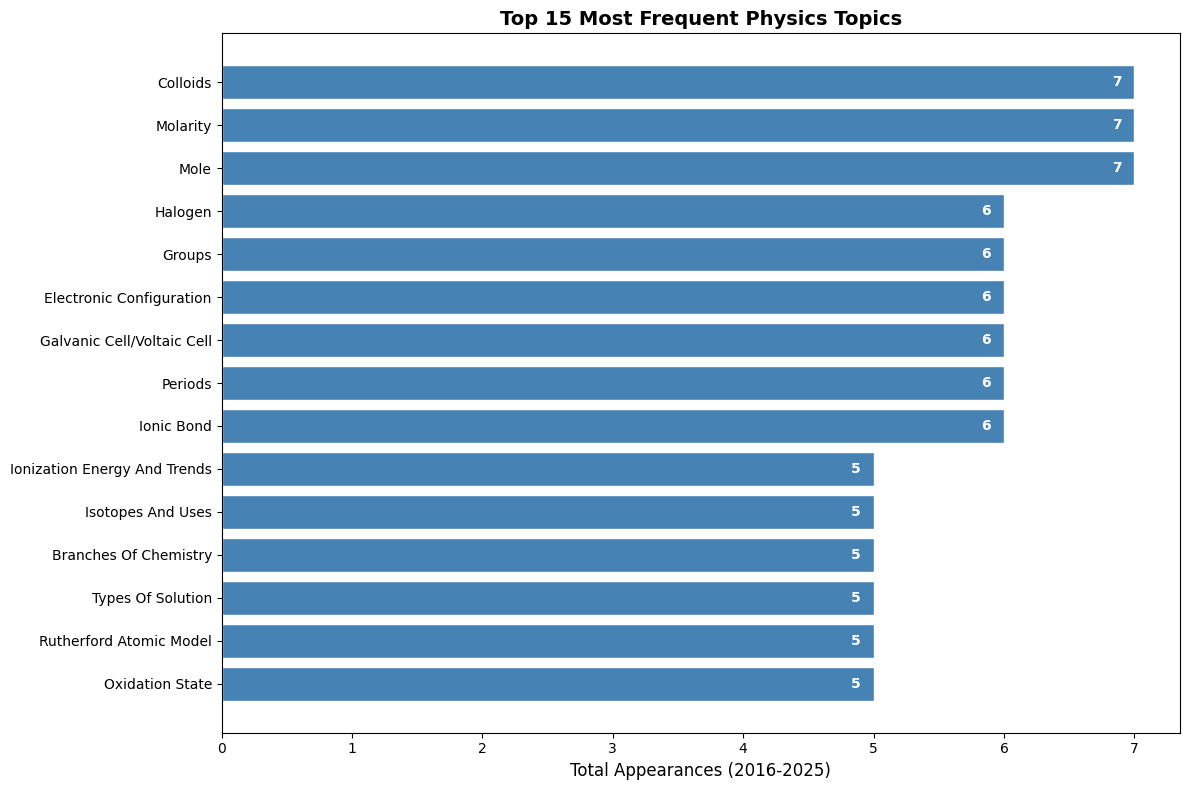

In [62]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Physics Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

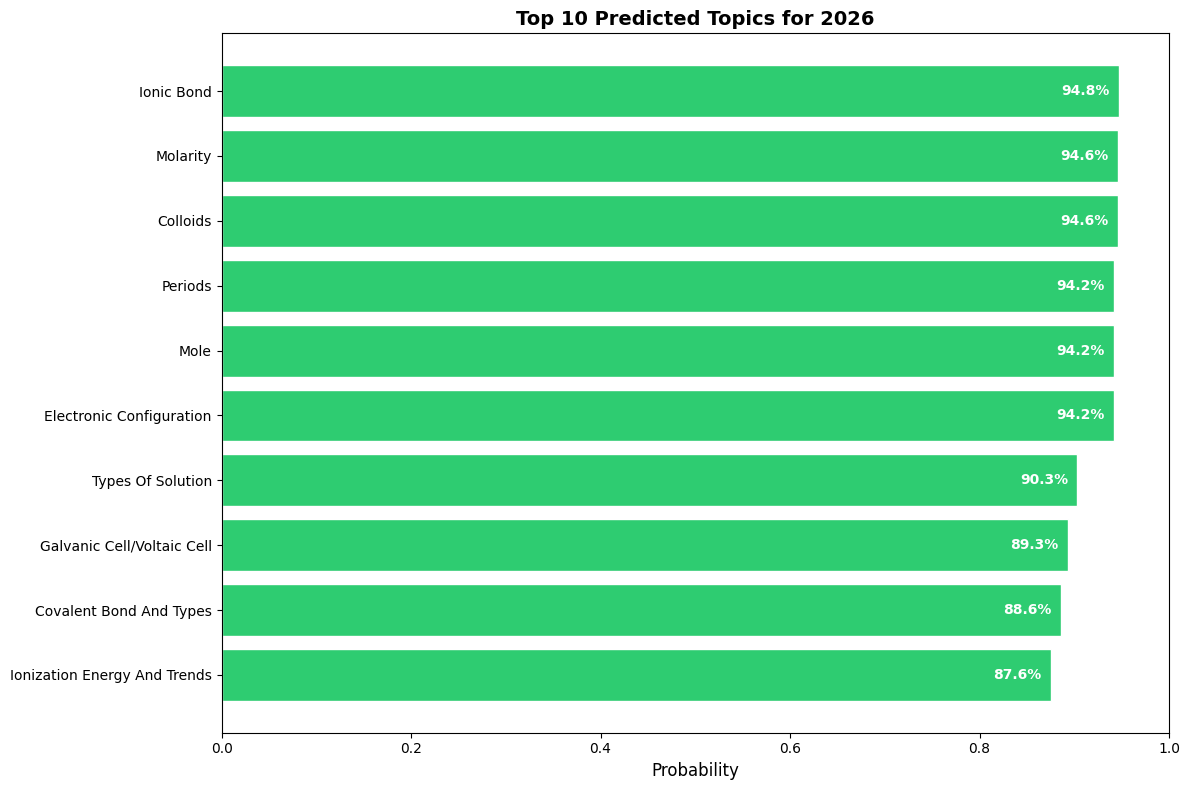

In [63]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Topic'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()

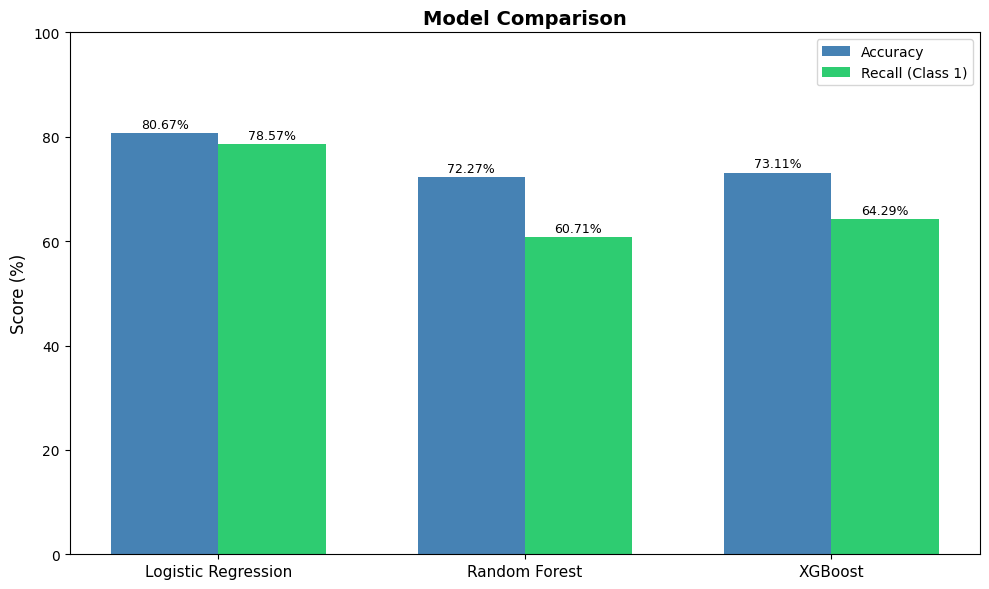

In [64]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [accuracy_lr*100, rf_accuracy*100, xg_accuracy*100]
recall = [recall_lr*100, rf_recall*100, xg_recall*100]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], accuracy, width, label='Accuracy', color='steelblue')
plt.bar([i + width/2 for i in x], recall, width, label='Recall (Class 1)', color='#2ecc71')

plt.ylabel('Score (%)', fontsize=12)
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, models, fontsize=11)
plt.legend()
plt.ylim(0, 100)

for i, (acc, rec) in enumerate(zip(accuracy, recall)):
    plt.text(i - width/2, acc + 1, f'{acc:.2f}%', ha='center', fontsize=9)
    plt.text(i + width/2, rec + 1, f'{rec:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('graph3_model_comparison.png', dpi=150)
plt.show()